# 03 — Preprocessing et feature engineering

**Projet** : Prédiction d'attrition client (churn télécom) avec XGBoost
**Objectif** : passer d'un dataset brut à une matrice numérique propre, **sans fuite de données**.

Ordre imposé (et testé dans `tests/test_preprocessing.py`) :

1. **split** d'abord (train / val / test),
2. **feature engineering** appris sur le train,
3. **preprocessing** (imputation, outliers, encodage, scaling) appris sur le train,
4. application aux autres splits — jamais l'inverse.

## Objectifs pédagogiques

1. Construire des features **déclaratives** (recettes YAML) plutôt que du code ad hoc.
1. Comprendre pourquoi toute statistique apprise sur le test fausse l'évaluation.
1. Configurer imputation, winsorising, encodage et scaling depuis `conf/preprocessing`.
1. Persister et recharger le pipeline : l'inférence doit reproduire exactement l'entraînement.

**Objectifs transverses du dépôt**

- Comprendre le gradient boosting : arbres séquentiels qui corrigent les résidus, shrinkage et régularisation.
- Utiliser l'early stopping natif (`eval_set` + `early_stopping_rounds`) sans réinventer la boucle d'entraînement.
- Régulariser un booster (max_depth, min_child_weight, subsample, colsample_bytree, reg_lambda, gamma).

In [1]:
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Racine du projet ---------------------------------------------------------------------------
# Le notebook s'exécute depuis `notebooks/` : on remonte d'un cran pour pouvoir importer `src`.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from hydra import compose, initialize_config_dir  # noqa: E402
from hydra.core.global_hydra import GlobalHydra  # noqa: E402
from loguru import logger  # noqa: E402

from src.schemas.config import validate_config  # noqa: E402
from src.utils.paths import ProjectPaths  # noqa: E402

# --- Réglages d'affichage -----------------------------------------------------------------------
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
logger.remove()
logger.add(sys.stderr, level="WARNING")

# --- Configuration : exactement celle de `python -m src.main` ------------------------------------
# Les notebooks travaillent sur un échantillon réduit (1500 lignes) : l'exécution complète
# reste sous la minute, tout en conservant des distributions réalistes.
NB_ROWS = 1500

GlobalHydra.instance().clear()
with initialize_config_dir(config_dir=str(PROJECT_ROOT / "conf"), version_base=None):
    CONFIG = validate_config(
        compose(
            config_name="config",
            overrides=[
                "mode=train",
                f"data.n_samples={NB_ROWS}",
                "seed=42",
                "log_level=WARNING",
                "++train.epochs=3",
                "train.callbacks.progress_bar=false",
            ],
        )
    )

PATHS = ProjectPaths.from_root(PROJECT_ROOT)
# Les notebooks écrivent leurs artefacts dans `outputs/notebooks` (ignoré par git) afin de ne
# jamais écraser ceux produits par `make train`.
NB_PATHS = ProjectPaths.from_root(PROJECT_ROOT / "outputs" / "notebooks").ensure()

print(f"Projet            : {CONFIG.project.name}")
print(f"Tâche             : {CONFIG.metrics.task}")
print(f"Métrique primaire : {CONFIG.metrics.primary} (seuil cible : 0.7)")
print(f"Cible             : {CONFIG.data.target}")
print(f"Algorithme        : {CONFIG.model.algorithm} ({CONFIG.model.name})")
print(f"Lignes (notebook) : {NB_ROWS}")

Projet            : telecom-churn-xgboost
Tâche             : binary
Métrique primaire : roc_auc (seuil cible : 0.7)
Cible             : churned
Algorithme        : xgboost (Gradient boosting XGBoost)
Lignes (notebook) : 1500


In [2]:
from src.data.generators import SyntheticDataGenerator
from src.data.loaders import RawDataLoader

raw_path = PATHS.data_file(CONFIG.data.dataset_name)
if raw_path.exists():
    # Cas nominal : le dataset a été généré par `make data`, on passe par le loader validant.
    raw = RawDataLoader(PATHS, dataset_name=CONFIG.data.dataset_name).load()
    print(f"Dataset lu depuis {raw_path.relative_to(PROJECT_ROOT)}")
else:
    # Le notebook reste exécutable sur un clone frais : on génère en mémoire.
    raw = SyntheticDataGenerator(n_samples=NB_ROWS, seed=CONFIG.data.seed).generate()
    print("data/raw vide : génération synthétique en mémoire (`make data` la persiste)")

raw = raw.head(NB_ROWS).reset_index(drop=True)
print(f"shape = {raw.shape}")
raw.head()

2026-09-13 06:05:42 | INFO     | src.data.loaders:_log_profile:183 - Loaded raw data | rows=4000 cols=15 missing_cells=317 memory=631.8 KB


Dataset lu depuis data/raw/telecom_churn.parquet
shape = (1500, 15)


,customer_id,signup_date,tenure_months,contract_type,internet_service,payment_method,region,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score,churned
0,CUS-00001,2024-12-21,13,two_year,dsl,electronic_check,south,51.89,680.43,1,83.89,2,0,7.57,0
1,CUS-00002,2022-05-03,45,two_year,dsl,credit_card,south,40.44,1849.09,0,138.90,3,0,7.41,0
2,CUS-00003,2023-07-21,30,two_year,none,mailed_check,west,20.11,606.84,1,3.18,5,0,7.48,0
3,CUS-00004,2025-12-01,2,month_to_month,dsl,credit_card,west,49.56,100.25,0,54.37,3,1,5.78,1
4,CUS-00005,2025-08-12,5,month_to_month,fiber,electronic_check,west,84.84,406.24,1,161.71,3,0,5.67,1


## 1. Splitter avant toute transformation

In [3]:
from src.data.loaders import DatasetSplitter, assert_no_overlap

splitter = DatasetSplitter.from_config(CONFIG.model_dump(), seed=CONFIG.data.seed)
splits = splitter.split(raw, target=CONFIG.data.target)

frames = [frame for frame in (splits.train, splits.val, splits.test) if frame is not None]
assert_no_overlap(*frames, key=CONFIG.data.id_column)
pd.DataFrame([splits.sizes], index=["lignes"]).T.assign(
    part=lambda frame: (frame["lignes"] / len(raw)).map("{:.1%}".format)
)

2026-09-13 06:05:42 | INFO     | src.data.loaders:split:505 - Split (random) | train=975 val=225 test=300 | stratify=True


,lignes,part
train,975,65.0%
val,225,15.0%
test,300,20.0%


**Ce qu'il faut retenir**

- `assert_no_overlap` est un garde-fou de fuite : aucune clé ne doit apparaître dans deux splits.
- La stratification conserve la répartition de la cible (indispensable en déséquilibre).
- Le split est **configuré** (`train.split.*`), jamais codé en dur : un sweep Hydra peut le faire varier.

## 2. Feature engineering déclaratif

In [4]:
from src.features.build_features import FeatureBuilder

builder = FeatureBuilder.from_config(CONFIG.model_dump(), target=CONFIG.data.target)
recipes = pd.DataFrame(builder.describe())
recipes if not recipes.empty else print(
    "Aucune recette déclarée dans conf/preprocessing/default.yaml"
)

,type,name,inputs,params
0,ratio,charges_per_tenure,"[monthly_charges, tenure_months]","{'numerator': 'monthly_charges', 'denominator'..."
1,ratio,tickets_per_product,"[support_tickets_6m, num_products]","{'numerator': 'support_tickets_6m', 'denominat..."
2,bin,tenure_bucket,[tenure_months],"{'column': 'tenure_months', 'method': 'quantil..."
3,boolean_flag,heavy_data_user,[avg_monthly_data_gb],"{'column': 'avg_monthly_data_gb', 'operator': ..."
4,boolean_flag,low_satisfaction,[satisfaction_score],"{'column': 'satisfaction_score', 'operator': '..."
5,group_stat,charges_by_contract,"[monthly_charges, contract_type]","{'group_by': 'contract_type', 'value_column': ..."
6,datetime_parts,signup_cohort,[signup_date],"{'column': 'signup_date', 'prefix': 'signup', ..."


**Ce qu'il faut retenir**

- Chaque recette est **déclarée en YAML** : ajouter une feature ne demande aucune modification de code.
- Le builder **refuse** une recette qui lirait la cible : la fuite la plus classique est bloquée à la configuration.
- Les recettes `bin` et `group_stat` apprennent des statistiques sur le train → elles nécessitent `fit()`.

In [5]:
if builder.recipes:
    builder.fit(splits.train)  # statistiques apprises sur le train uniquement
    enriched_train = builder.transform(splits.train)
    enriched_test = builder.transform(splits.test)
    created = [column for column in enriched_train.columns if column not in splits.train.columns]
    print(f"features créées : {created}")
    enriched_train[created].describe().T.round(3)
else:
    enriched_train, enriched_test, created = splits.train, splits.test, []
    print("Aucune feature dérivée.")

2026-09-13 06:05:42 | INFO     | src.features.build_features:fit:257 - FeatureBuilder fitted | recipes=7 learned=['charges_by_contract', 'tenure_bucket']


features créées : ['charges_per_tenure', 'tickets_per_product', 'tenure_bucket', 'heavy_data_user', 'low_satisfaction', 'charges_by_contract', 'signup_year', 'signup_month', 'signup_quarter']


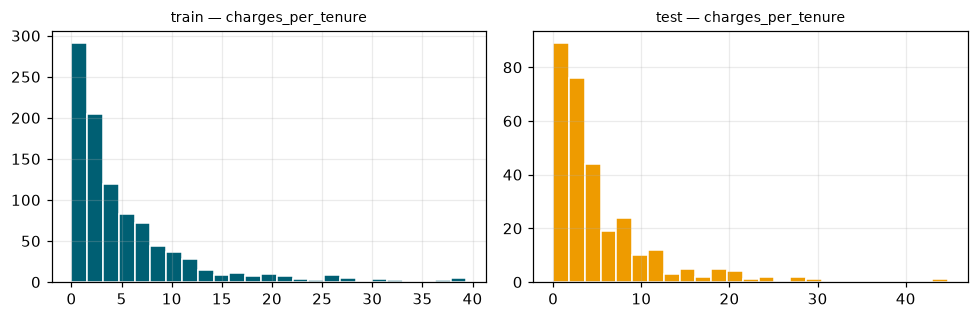

moyenne train = 5.4108
moyenne test  = 5.2051


In [6]:
# Stabilité d'une feature dérivée entre train et test : un bon signal doit se transporter.
if created:
    column = created[0]
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0))
    enriched_train[column].hist(bins=25, ax=axes[0], color="#005f73", edgecolor="white")
    axes[0].set_title(f"train — {column}", fontsize=9)
    enriched_test[column].hist(bins=25, ax=axes[1], color="#ee9b00", edgecolor="white")
    axes[1].set_title(f"test — {column}", fontsize=9)
    fig.tight_layout()
    plt.show()
    print(f"moyenne train = {enriched_train[column].mean():.4f}")
    print(f"moyenne test  = {enriched_test[column].mean():.4f}")
else:
    print("Aucune feature dérivée à comparer.")

**Ce qu'il faut retenir**

- Deux distributions très différentes entre train et test signalent une **dérive** (ou un split temporel).
- Une feature dont la moyenne change beaucoup apportera peu en production : à surveiller (voir `mlops/model-monitoring`).

## 3. Le pipeline de preprocessing

In [7]:
from src.data.loaders import DatasetSplitter, feature_target_split
from src.features.build_features import FeatureBuilder, select_feature_columns, split_by_dtype
from src.preprocessing.pipelines import PreprocessingPipeline


def prepare_matrices(frame: pd.DataFrame, config: Any) -> dict[str, Any]:
    """Reproduce what ``TrainPipeline`` does, on the notebook-sized dataset.

    La fonction reprend **exactement** l'enchaînement de production : split → feature
    engineering (appris sur train uniquement) → preprocessing (appris sur train uniquement).
    C'est ce qui rend les chiffres de ce notebook comparables à ceux de `make train`.

    Args:
        frame: Raw dataset.
        config: Validated application configuration.

    Returns:
        Mapping with splits, fitted objects and model-ready matrices.
    """
    target = config.data.target
    drop_columns = list(config.data.drop_columns)

    splitter = DatasetSplitter.from_config(config.model_dump(), seed=config.seed)
    splits = splitter.split(frame, target=target)

    builder = FeatureBuilder.from_config(config.model_dump(), target=target)
    if builder.recipes:
        builder.fit(splits.train)
    enriched = {
        "train": builder.transform(splits.train),
        "val": None if splits.val is None else builder.transform(splits.val),
        "test": builder.transform(splits.test),
    }

    train_frame = enriched["train"]
    feature_columns = select_feature_columns(train_frame, drop_columns=drop_columns, target=target)
    numeric, categorical = split_by_dtype(train_frame, feature_columns)
    explicit = config.preprocessing.model_dump().get("columns") or {}
    numeric = list(explicit.get("numeric") or numeric)
    categorical = list(explicit.get("categorical") or categorical)

    pipeline = PreprocessingPipeline(
        numeric_features=numeric,
        categorical_features=categorical,
        config=config.preprocessing.model_dump(),
        target=target,
    )
    X_train_frame, y_train = feature_target_split(train_frame, target, drop_columns)
    X_train = pipeline.fit_transform(X_train_frame, y_train)

    def project(split: pd.DataFrame | None) -> tuple[pd.DataFrame | None, Any]:
        if split is None:
            return None, None
        _, labels = feature_target_split(split, target, drop_columns)
        return pipeline.transform(split.loc[:, X_train_frame.columns]), labels

    X_val, y_val = project(enriched["val"])
    X_test, y_test = project(enriched["test"])

    return {
        "splits": splits,
        "enriched": enriched,
        "builder": builder,
        "pipeline": pipeline,
        "numeric": numeric,
        "categorical": categorical,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
        "feature_names": list(pipeline.feature_names_out),
    }


PREPARED = prepare_matrices(raw, CONFIG)
print("train :", PREPARED["X_train"].shape)
print("val   :", None if PREPARED["X_val"] is None else PREPARED["X_val"].shape)
print("test  :", PREPARED["X_test"].shape)
print(f"features livrées au modèle : {len(PREPARED['feature_names'])}")
PREPARED["X_train"].head()

2026-09-13 06:05:43 | INFO     | src.data.loaders:split:505 - Split (random) | train=975 val=225 test=300 | stratify=True


2026-09-13 06:05:43 | INFO     | src.features.build_features:fit:257 - FeatureBuilder fitted | recipes=7 learned=['charges_by_contract', 'tenure_bucket']


2026-09-13 06:05:43 | INFO     | src.preprocessing.pipelines:fit:318 - Fitting preprocessing | rows=975 numeric=17 categorical=4 encoder=onehot scaler=standard


2026-09-13 06:05:43 | INFO     | src.preprocessing.pipelines:fit:332 - Preprocessing fitted | output_features=31


train : (975, 31)
val   : (225, 31)
test  : (300, 31)
features livrées au modèle : 31


,tenure_months,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products,has_promotion,satisfaction_score,charges_per_tenure,tickets_per_product,tenure_bucket,heavy_data_user,low_satisfaction,charges_by_contract,signup_year,signup_month,signup_quarter,contract_type_month_to_month,contract_type_one_year,contract_type_two_year,internet_service_dsl,internet_service_fiber,internet_service_none,payment_method_bank_transfer,payment_method_credit_card,payment_method_electronic_check,payment_method_mailed_check,region_east,region_north,region_south,region_west
0,-0.454667,-0.376656,-0.100429,-0.936103,-0.677167,1.815339,-0.554049,0.352466,-0.338491,-0.862593,-0.385793,-0.4381,-0.111629,-0.909537,0.226664,1.318529,1.347130,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.947387,-1.777863,-2.166664,-0.936103,-1.189225,-0.636123,1.804894,0.676763,-0.187523,-0.862593,-1.262595,-0.4381,-0.111629,-0.878735,0.845706,0.737351,0.456654,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.898115,0.669337,-0.794432,-0.036004,-0.161837,-0.636123,-0.554049,0.268389,0.997783,0.066669,-1.262595,-0.4381,-0.111629,-0.909537,0.845706,0.446762,0.456654,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.602483,-1.920453,-1.320154,-0.936103,-1.184157,-0.636123,-0.554049,-0.464283,-0.617402,-0.862593,-0.385793,-0.4381,-0.111629,-0.878735,0.845706,-1.296772,-1.324298,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.185869,-0.129265,0.611829,-0.936103,-0.739353,0.998185,-0.554049,0.760840,-0.552362,-0.862593,0.491009,-0.4381,-0.111629,-0.878735,-0.392377,1.027940,1.347130,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


**Ce qu'il faut retenir**

- `prepare_matrices()` reproduit exactement `TrainPipeline` : les chiffres du notebook sont comparables à `make train`.
- Le nombre de features livrées dépasse celui des colonnes brutes : l'encodage one-hot **explose** les modalités.

In [8]:
report = PREPARED["pipeline"].report.to_dict()
pd.DataFrame(
    {
        "indicateur": [
            "lignes en entrée",
            "colonnes en entrée",
            "features en sortie",
            "manquants avant",
            "manquants après",
            "encodeur",
            "scaler",
        ],
        "valeur": [
            report["n_rows_in"],
            report["n_columns_in"],
            report["n_output_features"],
            report["missing_before"],
            report["missing_after"],
            report["encoder"],
            report["scaler"],
        ],
    }
)

,indicateur,valeur
0,lignes en entrée,975
1,colonnes en entrée,21
2,features en sortie,31
3,manquants avant,74
4,manquants après,0
5,encodeur,onehot
6,scaler,standard


**Ce qu'il faut retenir**

- `missing_before` > 0 et `missing_after` = 0 : l'imputation a fait son travail (et c'est **tracé**).
- Le rapport est sérialisable : il alimente les runs MLflow/W&B et le rapport d'évaluation.

In [9]:
from src.data.schemas import ProcessedDataSchema

X_train, X_test = PREPARED["X_train"], PREPARED["X_test"]
print("contrat processed :", "OK" if ProcessedDataSchema.validate(X_train) is not None else "KO")
print("dtypes uniques    :", sorted({str(dtype) for dtype in X_train.dtypes}))
print("NaN restants      :", int(X_train.isna().to_numpy().sum()))
X_train.iloc[:5, :6]

contrat processed : OK
dtypes uniques    : ['float64']
NaN restants      : 0


,tenure_months,monthly_charges,total_charges,support_tickets_6m,avg_monthly_data_gb,num_products
0,-0.454667,-0.376656,-0.100429,-0.936103,-0.677167,1.815339
1,-0.947387,-1.777863,-2.166664,-0.936103,-1.189225,-0.636123
2,-0.898115,0.669337,-0.794432,-0.036004,-0.161837,-0.636123
3,-0.602483,-1.920453,-1.320154,-0.936103,-1.184157,-0.636123
4,0.185869,-0.129265,0.611829,-0.936103,-0.739353,0.998185


## 4. Démonstration d'anti-fuite

In [10]:
# Le scaler est appris sur le train : le test est centré/réduit avec les statistiques du TRAIN.
train_mean = float(PREPARED["X_train"].to_numpy().mean())
test_mean = float(PREPARED["X_test"].to_numpy().mean())

# Contre-exemple volontaire : un pipeline appris sur train+test (fuite) puis comparé.
leaky = PreprocessingPipeline(
    numeric_features=PREPARED["numeric"],
    categorical_features=PREPARED["categorical"],
    config=CONFIG.preprocessing.model_dump(),
    target=CONFIG.data.target,
)
combined = pd.concat(
    [
        PREPARED["enriched"]["train"].drop(
            columns=list(CONFIG.data.drop_columns)
            + ([CONFIG.data.target] if CONFIG.data.target else []),
            errors="ignore",
        ),
        PREPARED["enriched"]["test"].drop(
            columns=list(CONFIG.data.drop_columns)
            + ([CONFIG.data.target] if CONFIG.data.target else []),
            errors="ignore",
        ),
    ],
    ignore_index=True,
)
_ = leaky.fit_transform(combined)

print(f"moyenne train (pipeline correct) : {train_mean:+.4f}")
print(f"moyenne test  (pipeline correct) : {test_mean:+.4f}  <- proche de 0 sans être 0 : normal")
print(f"colonnes du pipeline fuyard      : {len(leaky.feature_names_out)}")
print("Le pipeline fuyard a vu le test : ses statistiques en dépendent (illustration uniquement).")

2026-09-13 06:05:43 | INFO     | src.preprocessing.pipelines:fit:318 - Fitting preprocessing | rows=1275 numeric=17 categorical=4 encoder=onehot scaler=standard


2026-09-13 06:05:43 | INFO     | src.preprocessing.pipelines:fit:332 - Preprocessing fitted | output_features=31


moyenne train (pipeline correct) : +0.1290
moyenne test  (pipeline correct) : +0.1459  <- proche de 0 sans être 0 : normal
colonnes du pipeline fuyard      : 31
Le pipeline fuyard a vu le test : ses statistiques en dépendent (illustration uniquement).


**Ce qu'il faut retenir**

- La moyenne du **train** est ≈ 0 (le scaler l'a centré) ; celle du **test** ne l'est pas exactement : c'est la signature d'un pipeline honnête.
- Un `StandardScaler` ajusté sur train+test injecte de l'information du test dans le train → métriques surévaluées.
- Même règle pour l'imputation, le winsorising, le target encoding et le binning par quantiles.

## 5. Les transformateurs maison, un par un

In [11]:
from src.preprocessing.transformers import (
    DataFrameScaler,
    OutlierClipper,
    RareCategoryGrouper,
    TypeCaster,
)

numeric_columns = PREPARED["numeric"]
categorical_columns = PREPARED["categorical"]
frame = PREPARED["enriched"]["train"]

clipper = OutlierClipper((0.01, 0.99), columns=numeric_columns[:3]).fit(frame)
print("bornes apprises (train) :")
for column, bounds in list(clipper.bounds_.items())[:3]:
    print(f"  {column:<28} [{bounds[0]:.2f} ; {bounds[1]:.2f}]")
clipped = clipper.transform(frame)
print("cellules écrêtées       :", clipper.report)

bornes apprises (train) :
  tenure_months                [1.00 ; 72.00]
  monthly_charges              [18.00 ; 96.33]
  total_charges                [52.91 ; 4131.02]
cellules écrêtées       : {'tenure_months': 7, 'monthly_charges': 10, 'total_charges': 20}


In [12]:
if categorical_columns:
    grouper = RareCategoryGrouper(min_frequency=0.01, max_categories=10).fit(
        frame[categorical_columns]
    )
    kept = {column: len(values) for column, values in grouper.kept_.items()}
    grouped = grouper.transform(frame[categorical_columns])
    print("modalités conservées :", kept)
    print("modalités `rare`     :", int((grouped.astype(str) == "rare").to_numpy().sum()))
else:
    print("Aucune colonne catégorielle dans ce projet.")

modalités conservées : {'contract_type': 3, 'internet_service': 3, 'payment_method': 4, 'region': 4}
modalités `rare`     : 0


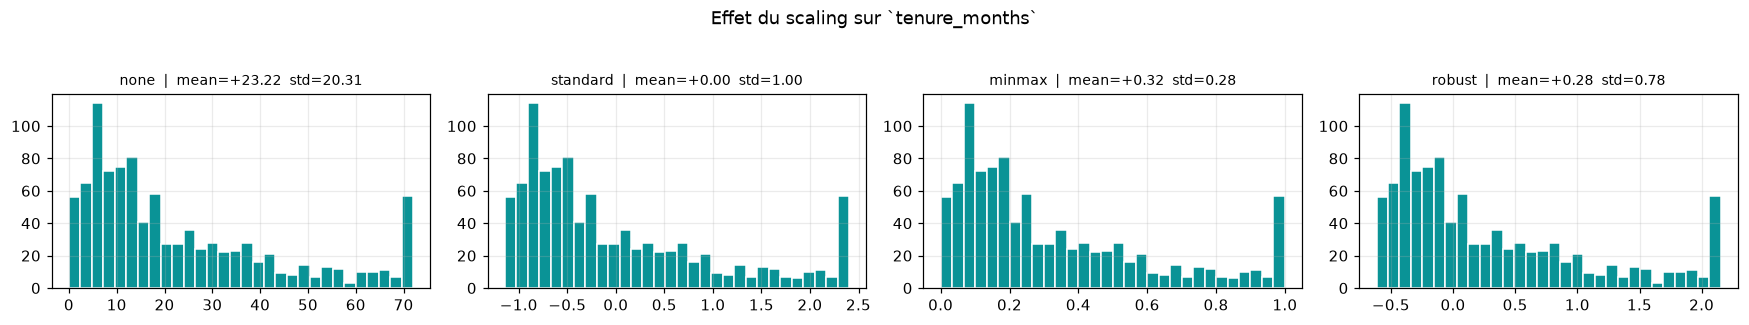

In [13]:
# Comparaison des stratégies de scaling sur une variable asymétrique.
column = numeric_columns[0]
strategies = ["none", "standard", "minmax", "robust"]
fig, axes = plt.subplots(1, len(strategies), figsize=(4.0 * len(strategies), 2.8), sharey=False)
for axis, strategy in zip(axes, strategies, strict=False):
    scaled = DataFrameScaler(strategy).fit_transform(frame[[column]])
    scaled[column].hist(bins=30, ax=axis, color="#0a9396", edgecolor="white")
    axis.set_title(
        f"{strategy}  |  mean={scaled[column].mean():+.2f}  std={scaled[column].std():.2f}",
        fontsize=9,
    )
fig.suptitle(f"Effet du scaling sur `{column}`", y=1.04)
fig.tight_layout()
plt.show()

**Ce qu'il faut retenir**

- `standard` : moyenne 0, écart-type 1 — le choix par défaut des modèles linéaires et des réseaux.
- `minmax` : ramène dans [0, 1] mais **sensibilise aux outliers** (le max définit l'échelle).
- `robust` : utilise médiane et écart interquartile — recommandé quand la queue est lourde.
- Les arbres (forêts, boosting) sont **invariants** au scaling : le scaler ne change rien à leurs splits.

In [14]:
# TypeCaster : projette un payload sur le contrat (utile en inférence,
# où des colonnes non déclarées arrivent du système appelant).
caster = TypeCaster(
    numeric_columns=numeric_columns[:3], categorical_columns=categorical_columns[:2]
).fit(frame)
noisy = frame.assign(colonne_inutile="x")
projected = caster.transform(noisy)
print("colonnes du payload bruité :", list(noisy.columns)[-3:])
print("colonnes après projection  :", list(projected.columns))
print("dtypes                     :", {str(k): str(v) for k, v in projected.dtypes.items()})

colonnes du payload bruité : ['signup_month', 'signup_quarter', 'colonne_inutile']
colonnes après projection  : ['tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service']
dtypes                     : {'tenure_months': 'float64', 'monthly_charges': 'float64', 'total_charges': 'float64', 'contract_type': 'category', 'internet_service': 'category'}


## 6. Persistance : l'inférence doit reproduire l'entraînement

In [15]:
test_frame = PREPARED["enriched"]["test"].loc[:, PREPARED["numeric"] + PREPARED["categorical"]]
artifact = PREPARED["pipeline"].save(NB_PATHS.models_dir / "preprocessing_notebook.joblib")
restored = PreprocessingPipeline.load(artifact)

before = PREPARED["pipeline"].transform(test_frame)
after = restored.transform(test_frame)

print("artefact      :", artifact.relative_to(PROJECT_ROOT))
print("features      :", before.shape[1])
print("reproductible :", bool(np.allclose(before.to_numpy(), after.to_numpy())))

artefact      : outputs/notebooks/artifacts/models/preprocessing_notebook.joblib
features      : 31
reproductible : True


**Ce qu'il faut retenir**

- Le pipeline est **sérialisé avec le modèle** : en inférence, aucune statistique n'est recalculée.
- Si `reproductible` est faux, l'artefact est corrompu ou les versions de librairies diffèrent (d'où la fiche modèle).

## 7. Synthèse

| Étape | Où c'est configuré | Test associé |
| --- | --- | --- |
| Split | `conf/train/default.yaml` (`split`) | `tests/test_loaders.py` |
| Features dérivées | `conf/preprocessing/default.yaml` (`features`) | `tests/test_preprocessing.py` |
| Imputation / outliers / encodage / scaling | `conf/preprocessing/default.yaml` | `tests/test_preprocessing.py` |
| Contrat de sortie | `src/data/schemas.py` (`ProcessedDataSchema`) | `tests/test_data_schemas.py` |

**Suite** : `04_model_exploration.ipynb` compare les algorithmes sur cette matrice.